<a href="https://colab.research.google.com/github/mamadou-thiaw/Apprentissage/blob/main/apprentissage_transfert_vgg16_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---
Apprentissage par transfert -TRANSFER LEARNING- AVEC VGG16 ET CIFAR10


---

**Transfer Learning :**

Le "transfer learning" est une approche en apprentissage automatique (machine learning) où un modèle pré-entrainé sur une tâche est utilisé comme point de départ pour résoudre une autre tâche similaire. Plutôt que de former un modèle à partir de zéro pour chaque tâche spécifique, le transfert d'apprentissage permet d'utiliser les connaissances acquises par un modèle sur une tâche source pour améliorer les performances sur une tâche cible.

**Architecture VGGNet :**


VGGNet (Visual Geometry Group") est une architecture de réseau de neurones profonds qui a été finaliste du défi ILSVRC ImageNet https://www.image-net.org/. ImageNet est de l'ordre de 100 Millions d'images sur l'enssemble de 100.000 mots du WordNet. Chaque mot (concept) est en moyenne illustré par 1000 images (250X250 pixels). Cette architecture est basée sur une répétition de blocs de deux ou trois couches de convolution et d'une couche de pooling pour atteindre un total de 16 ou 19 couches de convolution, ainsi qu'un réseau de final de deux couches cachées et la couche de sortie. Elle utilisait uniquement des filtres 3x3. Ce modèle est donc entrainé sur le jeu de données ImageNet reconnaissant l'ensemble des concepts-images.


---
Le but consiste donc  à entraîner le modèle sur un jeu de données spécifique (CIFAR-10) tout en initiant les poids du modèle avec les valeurs préalablement apprises à partir d'un modèle pré-entraîné sur une tâche similaire. Cela permettra d'ajuster les paramètres du modèle pour qu'ils soient mieux adaptés à la tâche cible, en capitalisant sur les connaissances préalables du modèle


Le dataset utilisé est le dataset CIFAR10 https://www.cs.toronto.edu/~kriz/cifar.html, qui contient 60 000 images 32x32 en couleur, réparties pour 10 classes différentes : Avion, Voiture , Oiseau, Chat , Biche, Chien, Grenouille, Cheval, Bateau, Camion.

---
Avant de commencer le transfert, nous allons explorer les  solutions suivantes pour montrer l'utilité d'un modèle pré-entrainé :
1. un modèle CNN sans  pré-entrainement et sans augmentation de données
2. un modèle CNN sans pré-entrainement et avec augmentation de données
3. un modèle CNN avec pré-entrainement en ré-utilisant le VGG16
4. CNN+VGG16+Augementation de données...À vous de jouer !



In [ ]:

#importation du modèle VGG16
from keras.applications import VGG16

#importation des modules communs
import tensorflow.keras as keras
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
import tensorflow as tf
from keras.models import load_model
from keras.datasets import cifar10
from keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from keras.utils import to_categorical

In [ ]:
#Chargement des données spécifiques

(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


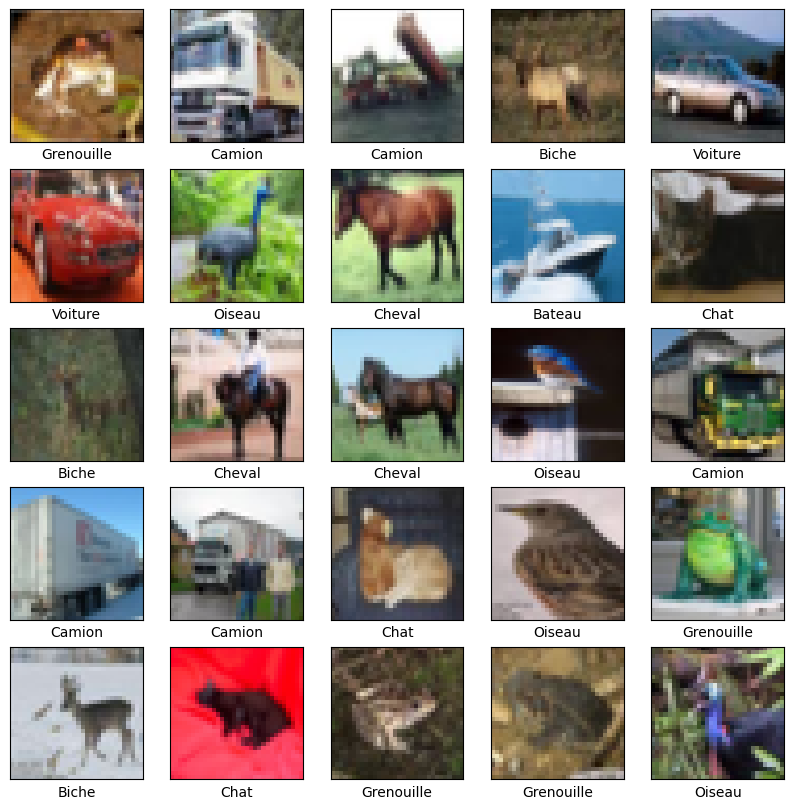

In [ ]:
class_names = ['Avion', 'Voiture' , 'Oiseau','Chat','Biche','Chien','Grenouille','Cheval','Bateau','Camion']
plt.figure(figsize=[10,10])
for i in range (25):    # for first 25 images
  plt.subplot(5, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(X_train_full[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[y_train_full[i][0]])

plt.show()

In [ ]:
#Normalisation par centrage-réduction et création d'un dataset de validation.


X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

#en codage des éqtiquettes pour l'utilisation de la fonction log-loss et softmax
y_train = to_categorical(y_train, 10)
y_valid = to_categorical(y_valid, 10)
y_test = to_categorical(y_test, 10)

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(45000, 32, 32, 3)
(5000, 32, 32, 3)
(10000, 32, 32, 3)


#Première solution: Utilisation d'un modèle CNN

In [ ]:
# definition de l'architecture.

from functools import partial

DefaultConv2D = partial(keras.layers.Conv2D,
                        kernel_size=3, activation='relu', padding="SAME")

model = keras.models.Sequential([
    DefaultConv2D(filters=32, kernel_size=7, input_shape=[32, 32, 3]),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=64),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=128),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │           4,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 228,874 (894.04 KB)

 Trainable params: 228,874 (894.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

#on utilise la descente du gradient comme optimiseur.
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
#le parametre verbose = 0 pour éviter l'affichage des messages en sortie sur la progression de l'entrainement
history = model.fit(X_train, y_train, epochs=25, validation_data=(X_valid, y_valid), verbose=2)


Epoch 1/25
1407/1407 - 8s - 6ms/step - accuracy: 0.3020 - loss: 1.8925 - val_accuracy: 0.4004 - val_loss: 1.6189
Epoch 2/25
1407/1407 - 6s - 4ms/step - accuracy: 0.4294 - loss: 1.5711 - val_accuracy: 0.5040 - val_loss: 1.3835
Epoch 3/25
1407/1407 - 5s - 4ms/step - accuracy: 0.4878 - loss: 1.4270 - val_accuracy: 0.4836 - val_loss: 1.4201
Epoch 4/25
1407/1407 - 5s - 4ms/step - accuracy: 0.5317 - loss: 1.3145 - val_accuracy: 0.5882 - val_loss: 1.1783
Epoch 5/25
1407/1407 - 4s - 3ms/step - accuracy: 0.5664 - loss: 1.2270 - val_accuracy: 0.5794 - val_loss: 1.2268
Epoch 6/25
1407/1407 - 3s - 2ms/step - accuracy: 0.5910 - loss: 1.1556 - val_accuracy: 0.6508 - val_loss: 1.0199
Epoch 7/25
1407/1407 - 5s - 4ms/step - accuracy: 0.6176 - loss: 1.0950 - val_accuracy: 0.6662 - val_loss: 0.9688
Epoch 8/25
1407/1407 - 4s - 3ms/step - accuracy: 0.6352 - loss: 1.0400 - val_accuracy: 0.6694 - val_loss: 0.9584
Epoch 9/25
1407/1407 - 5s - 3ms/step - accuracy: 0.6516 - loss: 0.9915 - val_accuracy: 0.7046 - 

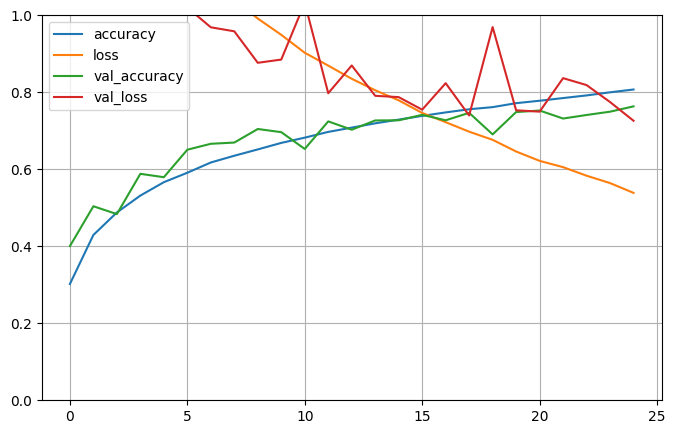

In [ ]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

Le résultat n'est pas au rendez-vous. l'exactitude est de l'ordre de 78% pour 25 époques avec un sur-ajustement. De plus, la tendance n'est pas à une forte  croissance. Nous allons opter pour la 2 solution: augmentation des données

L'augmentation des données consiste à générer davantage de données d'aprentissage à partir des exemples d'apprentissage déjà existants. Elle augmente le nombre d'exemples en effectuant un certain nombre de transformations aléatoires qui produisent des images d'apprence plausibles. Son objectif est qu'au moment de l'entrainement votre modèle ne sera jamais confronté exactement à la même image deux fois. Cette technique permet d'exposer le modèle à davantage d'aspects des données, et elle l'aide à mieux généraliser.

Mise en oeuvre de l'augmentation des données à l'aide de l'instance ImagedataGenerator. Ce sont quelques-unes des options:
1. rotation_range: est une valeur en degrés (0-180), un intervalle à l'intérieur duquel les images peuvent effectuer aléatoirement une rotation
2. witdh_shift et height_shift: ce sont des intervalles où l'image peut être translater aléatoirement, horizontalemment ou verticalement.
3. horizonatl_flip: retourner horizontalement la moitié de l'image

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

On fait maintenant appel à la fonction fit() pour l'entrainement du réseau au cours du quel on génére de nouveaux lots d'image à l'aide de la fonction flow du générateur d'image (instance datagen), à partir du jeu d'entrainement de base X_train

In [ ]:
history= model.fit(datagen.flow(X_train, y_train, batch_size=32),
          validation_data=datagen.flow(X_valid, y_valid,batch_size=8), epochs=25)

Epoch 1/25


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.2098 - loss: 2.1042 - val_accuracy: 0.3644 - val_loss: 1.7384
Epoch 2/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.3382 - loss: 1.8147 - val_accuracy: 0.4118 - val_loss: 1.6209
Epoch 3/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.3751 - loss: 1.7095 - val_accuracy: 0.4458 - val_loss: 1.5346
Epoch 4/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.3981 - loss: 1.6433 - val_accuracy: 0.4658 - val_loss: 1.4840
Epoch 5/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.4244 - loss: 1.5882 - val_accuracy: 0.4678 - val_loss: 1.4796
Epoch 6/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.4411 - loss: 1.5371 - val_accuracy: 0.5008 - val_loss: 1.3661
Epoch 7/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.4599 - loss: 1.4987 - val_accuracy: 0.5242 - val_loss: 1.3308
Epoch 8/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.4847 - loss: 1.44

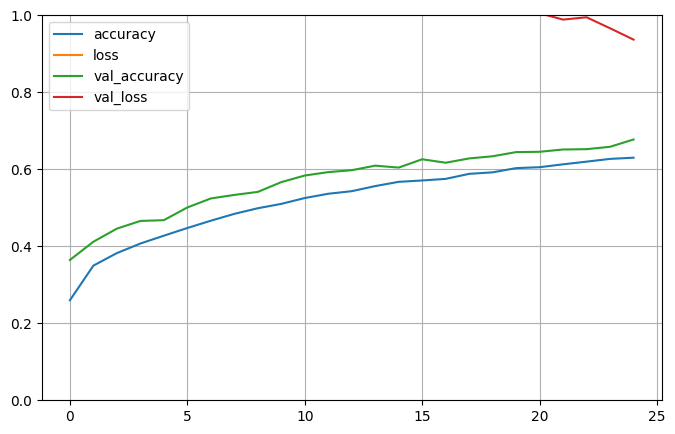

In [ ]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

On constate que le problème du sur-ajustement est reglé mais la performance demeure presque la même que précédemment avec une légère augmentation, de l'orde de 79%. À partir de là, nous allons tenter de recourir au modèle pré-entrainé VGG16.


#Solution 3: utilisation du modèle VGG16

Transmission d'arguments au constructeur de la classe VGG16:

1. l'argument weights spécifie le weight checkpoint à partir duquel le modèle est initialisé
2. include_top: réfère à l'inclusion (ou non) du classifieur entièrement connecté sur la partie supérieure du réseau; par défaut, ce classifieur entèrement connecté correspond aux 1000 classes d'ImageNet. Comme, dans notre cas, nous allons utiliser notre propre classifieur (avec seulement 10 classes), nous n'avons pas besoin de l'inclure
3. input_shape indique la forme des tenseurs d'images que vous allez envoyer au réseau: cet argument est purement optionnel: si vous ne le passez pas, le réseau pourra s'adapter



In [ ]:
conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Voici le détail de l'architecture de la base de convolution du VGG16.
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 2, 2, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

La carte de caractéristique finale a la forme (4,4,512). C'est la carte sur laquelle vous ajouterez un classifeur entièrement connecté.
Parce que les modèles se comportent comme des couches, vous pouvez ajouter un modèle (conv_base) à un modèle Sequential exactement comme vous ajouteriez une couche

On ajoute donc au block définissant le VGG16, la couche flatten pour aplatir les résultats du VGG,, vue comme un block de convolution. On met également des couches de normalisation (BatchNormalisation) pour accélérer la convergence de notre modèle.
On ajoute une couche Droput pour éviter le surajustement du modèle.


In [ ]:
#Ajout  d'un classifieur entièrement connecté au-dessus de la base de convolution
#remarquer qu'on entraine sans augmentation de données...!

In [ ]:
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.BatchNormalization())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5), loss='categorical_crossentropy', metrics=['acc'])

history = model.fit(X_train, y_train, epochs=25, batch_size=20, validation_data=(X_valid, y_valid))

Epoch 1/25
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 77s 30ms/step - acc: 0.1879 - loss: 2.5335 - val_acc: 0.5686 - val_loss: 1.3431
Epoch 2/25
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 64s 29ms/step - acc: 0.4645 - loss: 1.6104 - val_acc: 0.7336 - val_loss: 0.8882
Epoch 3/25
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - acc: 0.6284 - loss: 1.2107 - val_acc: 0.7520 - val_loss: 0.8171
Epoch 4/25
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - acc: 0.7073 - loss: 1.0209 - val_acc: 0.7882 - val_loss: 0.6912
Epoch 5/25
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - acc: 0.7587 - loss: 0.8764 - val_acc: 0.7944 - val_loss: 0.6892
Epoch 6/25
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 64s 29ms/step - acc: 0.7985 - loss: 0.7566 - val_acc: 0.8322 - val_loss: 0.5518
Epoch 7/25
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - acc: 0.8341 - loss: 0.6578 - val_acc: 0.8252 - val_loss: 0.5714
Epoch 8/25
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - acc: 0.8554 - loss: 0.5857 - val_acc: 0.8530 - val_loss: 0.5032
Epoch 9/25
2250/2250 ━━━

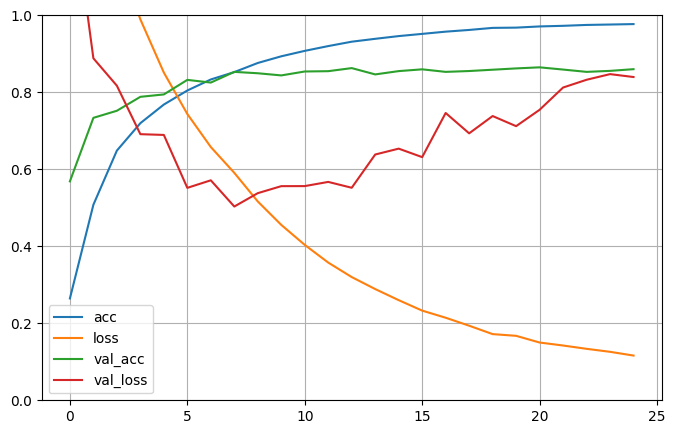

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

On constate qu'il y a une nette amélioration de la performance du modèle. C'est de l'ordre de 85%. Par contre, il y a du sur-ajustement. Pour y rémédier, c'est de refaire la même démarche que précédemment. Tenter d'entrainer le modèle pré-entrainé avec une augmentation de données. A vous de jouer !
